## Skeleton-Transformer v2 — Training Dynamics Fix

Uses existing `../M4B_skeleton_clips_v2` data.

**The problem:** Every Transformer config peaked at epoch 1-2 then declined. The model learned good initial features but the optimizer destroyed them by overfitting to noisy keypoints.

**Four fixes targeting training dynamics (not architecture):**

1. **Staged training** — freeze the Transformer body for the first 10 epochs, train only the classifier head. Then unfreeze with 10x lower LR. This preserves the good initial representations.

2. **EMA (Exponential Moving Average)** — maintain a smoothed copy of model weights. The EMA model averages out the epoch-to-epoch oscillation and is typically 2-5% better than the best single checkpoint.

3. **Skeleton mixup** — blend pairs of skeleton clips (0.7×clip_A + 0.3×clip_B with mixed labels). Unlike pixel mixup (meaningless for CNN+LSTM because backgrounds blend), skeleton mixup creates realistic intermediate motion patterns that regularize the decision boundary.

4. **CosineAnnealingWarmRestarts** — reset the LR periodically so the model gets multiple chances to find good solutions, not just one shot that decays monotonically.

**Architecture:** Config B (d=128, 4 layers) — the previous winner.

In [1]:
import os, cv2, gc, random, time, sys, math, copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import recall_score, precision_score
from pathlib import Path
import matplotlib.pyplot as plt

SKEL_ROOT       = r'../M4B_skeleton_clips_v2'
TARGET_CLASSES  = ['Violence', 'Threat', 'Normal']
SKEL_CLIP_FRAMES = 16
MAX_PERSONS     = 2
N_KEYPOINTS     = 17

EPOCHS       = 120
BATCH        = 32
LR_HEAD      = 1e-3     # higher LR for classifier head (first 10 epochs)
LR_FULL      = 5e-5     # much lower LR when unfreezing transformer
FREEZE_EPOCHS = 10      # freeze transformer body for this many epochs
PATIENCE     = 30       # generous patience since we have staged training
EMA_DECAY    = 0.998    # EMA smoothing factor
MIXUP_ALPHA  = 0.3      # mixup blending strength

SAVE_PATH = r'runs/M4B_classifier/TransformerV2/best.pt'
SAVE_EMA  = r'runs/M4B_classifier/TransformerV2/best_ema.pt'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

for split in ['train', 'val']:
    total = sum(len(list((Path(SKEL_ROOT)/split/c).glob('*.npy')))
                for c in TARGET_CLASSES if (Path(SKEL_ROOT)/split/c).exists())
    print(f'  {split}: {total:,} clips')

print(f'\nTraining plan:')
print(f'  Epoch 1-{FREEZE_EPOCHS}: head only (lr={LR_HEAD})')
print(f'  Epoch {FREEZE_EPOCHS+1}-{EPOCHS}: full model (lr={LR_FULL})')
print(f'  EMA decay: {EMA_DECAY}')
print(f'  Mixup alpha: {MIXUP_ALPHA}')


Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
  train: 11,200 clips
  val: 2,800 clips

Training plan:
  Epoch 1-10: head only (lr=0.001)
  Epoch 11-120: full model (lr=5e-05)
  EMA decay: 0.998
  Mixup alpha: 0.3


In [2]:
BONES = [(5,7),(7,9),(6,8),(8,10),(5,6),(11,13),(13,15),(12,14),(14,16),(11,12),(5,11),(6,12),(0,5),(0,6),(0,1),(0,2)]
ANGLE_TRIPLETS = [(5,7,9),(6,8,10),(11,13,15),(12,14,16),(5,0,6)]

def compute_bones(kps):
    out = []
    for j1, j2 in BONES:
        dx, dy = kps[j1,0]-kps[j2,0], kps[j1,1]-kps[j2,1]
        out.append(math.sqrt(dx*dx + dy*dy + 1e-8))
    return np.array(out, dtype=np.float32)

def compute_angles(kps):
    out = []
    for a, v, b in ANGLE_TRIPLETS:
        va, vb = kps[a]-kps[v], kps[b]-kps[v]
        c = np.dot(va, vb) / (np.linalg.norm(va)*np.linalg.norm(vb) + 1e-8)
        out.append(math.acos(np.clip(c, -1, 1)) / math.pi)
    return np.array(out, dtype=np.float32)

def compute_inter(k1, k2):
    c1, c2 = k1[:,:2].mean(0), k2[:,:2].mean(0)
    cd = np.linalg.norm(c1-c2)
    md = np.linalg.norm(k1[:,:2][:,None]-k2[:,:2][None,:], axis=2).min()
    hh = min(np.linalg.norm(k1[9,:2]-k2[0,:2]), np.linalg.norm(k1[10,:2]-k2[0,:2]),
             np.linalg.norm(k2[9,:2]-k1[0,:2]), np.linalg.norm(k2[10,:2]-k1[0,:2]))
    return np.array([cd, md, hh], dtype=np.float32)

class TransformerSkeletonDataset(Dataset):
    def __init__(self, root, split, classes, augment=False, feat_mean=None, feat_std=None):
        self.samples = []
        self.augment = augment
        self.feat_mean = feat_mean
        self.feat_std = feat_std
        base = Path(root) / split
        for ci, cls in enumerate(classes):
            d = base / cls
            if d.exists():
                for p in d.glob('*.npy'):
                    self.samples.append((p, ci))
        random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def _mask_low_conf(self, clip):
        for p in range(MAX_PERSONS):
            valid = clip[:, p, :, 2] > 0.3
            for j in range(N_KEYPOINTS):
                if valid[:, j].sum() > 0:
                    mp = clip[valid[:, j], p, j, :2].mean(0)
                else:
                    mp = np.array([0.5, 0.5])
                for t in range(clip.shape[0]):
                    if not valid[t, j]:
                        clip[t, p, j, :2] = mp
                        clip[t, p, j, 2] = 0.0
        return clip

    def _build(self, clip):
        T = clip.shape[0]
        clip = self._mask_low_conf(clip)
        rows = []
        for t in range(T):
            f = []
            for p in range(MAX_PERSONS):
                k = clip[t, p]
                f.extend([k[:,:2].flatten(), k[:,2], compute_bones(k), compute_angles(k)])
            f.append(compute_inter(clip[t,0], clip[t,1]))
            rows.append(np.concatenate(f))
        feat = np.stack(rows)
        psize = 34+17+16+5
        for p in range(MAX_PERSONS):
            s = p * psize
            pos = feat[:, s:s+34]
            vel = np.zeros_like(pos); vel[1:] = pos[1:]-pos[:-1]
            acc = np.zeros_like(vel); acc[2:] = vel[2:]-vel[1:-1]
            feat = np.concatenate([feat, vel, acc], axis=1)
        return feat

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        clip = np.load(str(path)).copy()
        if self.augment:
            if random.random() > 0.5:
                clip[:,:,:,0] = 1.0 - clip[:,:,:,0]
                for l, r in [(1,2),(3,4),(5,6),(7,8),(9,10),(11,12),(13,14),(15,16)]:
                    clip[:,:,[l,r]] = clip[:,:,[r,l]]
            dx, dy = random.uniform(-0.05,0.05), random.uniform(-0.05,0.05)
            clip[:,:,:,0] = np.clip(clip[:,:,:,0]+dx, 0, 1)
            clip[:,:,:,1] = np.clip(clip[:,:,:,1]+dy, 0, 1)
            s = random.uniform(0.85, 1.15)
            for p in range(MAX_PERSONS):
                cx, cy = clip[:,p,:,0].mean(), clip[:,p,:,1].mean()
                clip[:,p,:,0] = np.clip((clip[:,p,:,0]-cx)*s+cx, 0, 1)
                clip[:,p,:,1] = np.clip((clip[:,p,:,1]-cy)*s+cy, 0, 1)
        feat = self._build(clip)
        if self.feat_mean is not None:
            feat = (feat - self.feat_mean) / (self.feat_std + 1e-8)
        return torch.tensor(feat, dtype=torch.float32), label

# Standardization
print('Computing feature statistics...')
tmp = TransformerSkeletonDataset(SKEL_ROOT, 'train', TARGET_CLASSES)
samples = [tmp[i][0].numpy() for i in range(min(2000, len(tmp)))]
all_feat = np.concatenate(samples, axis=0)
FEAT_MEAN = all_feat.mean(axis=0)
FEAT_STD  = all_feat.std(axis=0)
FEAT_DIM  = FEAT_MEAN.shape[0]
del tmp, samples, all_feat
print(f'Feature dim: {FEAT_DIM} ✅')


Computing feature statistics...
Feature dim: 283 ✅


In [3]:
class SkeletonTransformer(nn.Module):
    """Config B architecture (winner from tuning round 1)."""
    def __init__(self, input_dim, num_classes=3, d_model=128,
                 nhead=4, num_layers=4, dim_ff=256, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout * 0.3),
        )
        self.pos_embed = nn.Parameter(torch.randn(1, SKEL_CLIP_FRAMES, d_model) * 0.02)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu',
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(d_model // 2, num_classes),
        )

    def forward(self, x):
        B = x.shape[0]
        x = self.input_proj(x)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        pos = torch.cat([torch.zeros(1, 1, x.shape[2], device=x.device),
                         self.pos_embed], dim=1)
        x = x + pos
        x = self.transformer(x)
        x = self.norm(x[:, 0])
        return self.head(x)


class EMA:
    """Exponential Moving Average of model weights."""
    def __init__(self, model, decay=0.998):
        self.decay = decay
        self.shadow = {}
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.clone()

    def update(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad and name in self.shadow:
                self.shadow[name] = self.decay * self.shadow[name] + (1-self.decay) * param.data

    def apply(self, model):
        """Copy EMA weights into model (for evaluation)."""
        backup = {}
        for name, param in model.named_parameters():
            if name in self.shadow:
                backup[name] = param.data.clone()
                param.data = self.shadow[name].clone()
        return backup

    def restore(self, model, backup):
        """Restore original weights after evaluation."""
        for name, param in model.named_parameters():
            if name in backup:
                param.data = backup[name]


def skeleton_mixup(x, y, alpha=0.3):
    """Mix pairs of skeleton clips with random blending."""
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    lam = max(lam, 1 - lam)  # ensure lam >= 0.5
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    return mixed_x, y, y[index], lam


model = SkeletonTransformer(FEAT_DIM).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'Model: Config B (d=128, 4 layers, 4 heads)')
print(f'Params: {n_params:,}')


C:\Users\jingy\AppData\Local\Temp\ipykernel_29064\1428634956.py:19: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Model: Config B (d=128, 4 layers, 4 heads)
Params: 577,411


Loading data...
  Train: 11,200  Val: 2,800
  Weights: {'Violence': 1.167, 'Threat': 1.167, 'Normal': 0.778}


C:\Users\jingy\AppData\Local\Temp\ipykernel_29064\1428634956.py:19: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)



  Skeleton-Transformer v2 — Training Dynamics Fix
  Stage 1 (ep 1-10): head only, lr=0.001
  Stage 2 (ep 11+): full model, lr=5e-05
  EMA decay=0.998, Mixup alpha=0.3
  Config B: d=128, 4 layers, 4 heads
  ep   1 [HEAD]  loss=0.8920  f1=0.5556  3m44s ✅ ✅(ema)
  ep   2 [HEAD]  loss=0.8263  f1=0.5157  5m44s ✅(ema)
  ep   3 [HEAD]  loss=0.8008  f1=0.5127  7m34s
  ep   4 [HEAD]  loss=0.7828  f1=0.4890  ema=0.5127  8m53s
  ep   5 [HEAD]  loss=0.7794  f1=0.5023  ema=0.5090  10m37s
  ep  10 [HEAD]  loss=0.7333  f1=0.4923  ema=0.5004  20m20s

  >>> UNFREEZING transformer body (lr=5e-05) <<<

  ep  11 [FULL]  loss=0.8158  f1=0.4883  ema=0.4832  22m20s
  ep  20 [FULL]  loss=0.6974  f1=0.4509  ema=0.4611  40m20s
  ep  28 [FULL]  loss=0.6889  f1=0.4903  ema=0.4772  56m20s
  ep  29 [FULL]  loss=0.6533  f1=0.4731  ema=0.4730  58m19s
  ep  30 [FULL]  loss=0.6612  f1=0.4404  ema=0.4600  60m19s
  ep  31 [FULL]  loss=0.6601  f1=0.4358  ema=0.4545  62m19s
  Early stop at epoch 31

Done in 62m19s
Best re

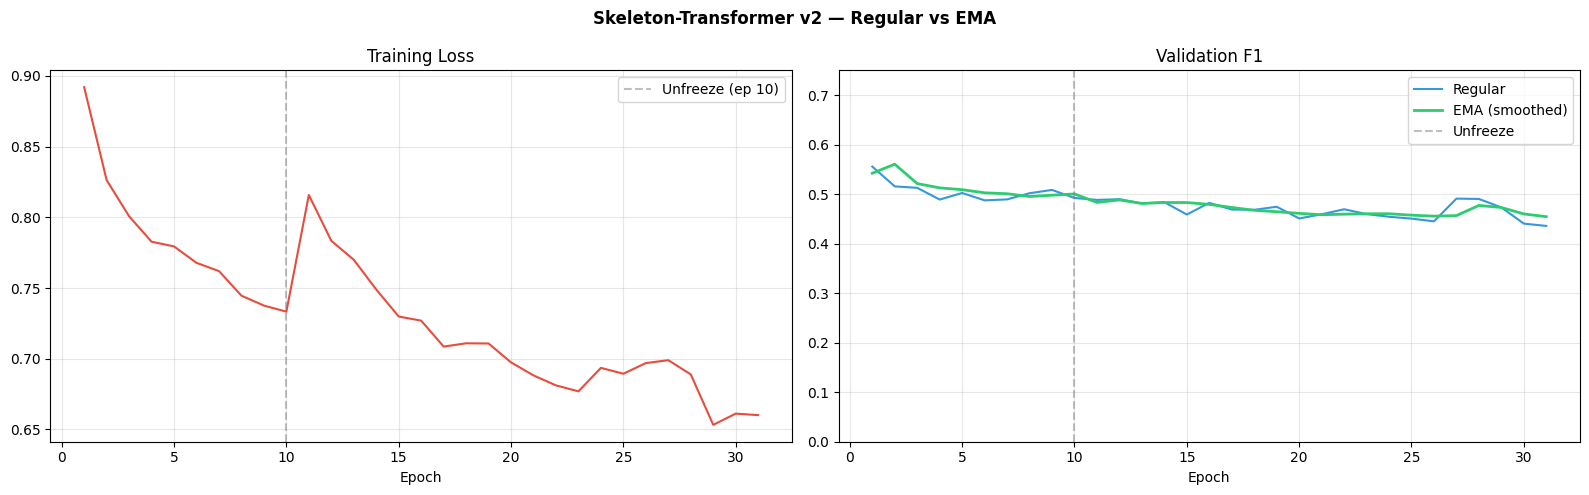

In [4]:
Path(SAVE_PATH).parent.mkdir(parents=True, exist_ok=True)

# Data
print('Loading data...')
train_ds = TransformerSkeletonDataset(SKEL_ROOT, 'train', TARGET_CLASSES,
                                       augment=True, feat_mean=FEAT_MEAN, feat_std=FEAT_STD)
val_ds   = TransformerSkeletonDataset(SKEL_ROOT, 'val', TARGET_CLASSES,
                                       augment=False, feat_mean=FEAT_MEAN, feat_std=FEAT_STD)
train_ld = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0, pin_memory=True)
val_ld   = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)
print(f'  Train: {len(train_ds):,}  Val: {len(val_ds):,}')

# Class weights
counts = [len(list((Path(SKEL_ROOT)/'train'/c).glob('*.npy'))) for c in TARGET_CLASSES]
total = sum(counts)
wts = torch.tensor([total/(3*c) for c in counts], dtype=torch.float).to(DEVICE)
print(f'  Weights: {dict(zip(TARGET_CLASSES, [round(w,3) for w in wts.tolist()]))}')

# Model
model = SkeletonTransformer(FEAT_DIM).to(DEVICE)
ema = EMA(model, decay=EMA_DECAY)
criterion = nn.CrossEntropyLoss(weight=wts)

# Stage 1 optimizer: head only
head_params = list(model.head.parameters()) + list(model.norm.parameters())
body_params = [p for n, p in model.named_parameters()
               if not any(x in n for x in ['head', 'norm'])]

# Freeze transformer body initially
for p in body_params:
    p.requires_grad = False

optimizer = optim.AdamW(head_params, lr=LR_HEAD, weight_decay=1e-2)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=15, T_mult=2, eta_min=1e-6)

print()
print('='*70)
print('  Skeleton-Transformer v2 — Training Dynamics Fix')
print(f'  Stage 1 (ep 1-{FREEZE_EPOCHS}): head only, lr={LR_HEAD}')
print(f'  Stage 2 (ep {FREEZE_EPOCHS+1}+): full model, lr={LR_FULL}')
print(f'  EMA decay={EMA_DECAY}, Mixup alpha={MIXUP_ALPHA}')
print(f'  Config B: d=128, 4 layers, 4 heads')
print('='*70)
sys.stdout.flush()

best_f1 = 0.0
best_f1_ema = 0.0
pat = 0
history = {'loss': [], 'f1': [], 'f1_ema': []}
best_yt, best_yp = [], []
best_yt_ema, best_yp_ema = [], []
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    # Stage transition: unfreeze at FREEZE_EPOCHS
    if epoch == FREEZE_EPOCHS + 1:
        print(f'\n  >>> UNFREEZING transformer body (lr={LR_FULL}) <<<\n')
        for p in body_params:
            p.requires_grad = True
        optimizer = optim.AdamW(model.parameters(), lr=LR_FULL, weight_decay=1e-2)
        scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=15, T_mult=2, eta_min=1e-6)

    # Train
    model.train()
    tloss = 0.0
    for clips, labels in train_ld:
        clips, labels = clips.to(DEVICE), labels.to(DEVICE)

        # Skeleton mixup (only after unfreezing)
        if epoch > FREEZE_EPOCHS and MIXUP_ALPHA > 0:
            clips_mix, labels_a, labels_b, lam = skeleton_mixup(clips, labels, MIXUP_ALPHA)
            optimizer.zero_grad()
            out = model(clips_mix)
            loss = lam * criterion(out, labels_a) + (1-lam) * criterion(out, labels_b)
        else:
            optimizer.zero_grad()
            out = model(clips)
            loss = criterion(out, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        ema.update(model)
        tloss += loss.item()

    tloss /= len(train_ld)
    scheduler.step()

    # Validate — regular model
    model.eval()
    yt, yp = [], []
    with torch.no_grad():
        for clips, labels in val_ld:
            preds = model(clips.to(DEVICE)).argmax(1).cpu().numpy()
            yt.extend(labels.numpy()); yp.extend(preds)
    vf1 = f1_score(yt, yp, average='weighted', zero_division=0)
    vacc = accuracy_score(yt, yp)

    # Validate — EMA model
    backup = ema.apply(model)
    yt_e, yp_e = [], []
    with torch.no_grad():
        for clips, labels in val_ld:
            preds = model(clips.to(DEVICE)).argmax(1).cpu().numpy()
            yt_e.extend(labels.numpy()); yp_e.extend(preds)
    vf1_ema = f1_score(yt_e, yp_e, average='weighted', zero_division=0)
    ema.restore(model, backup)

    history['loss'].append(tloss)
    history['f1'].append(vf1)
    history['f1_ema'].append(vf1_ema)

    # Track best
    improved = ''
    if vf1 > best_f1:
        best_f1 = vf1
        best_yt, best_yp = yt, yp
        torch.save(model.state_dict(), SAVE_PATH)
        pat = 0
        improved = ' ✅'
    else:
        pat += 1

    if vf1_ema > best_f1_ema:
        best_f1_ema = vf1_ema
        best_yt_ema, best_yp_ema = yt_e, yp_e
        backup = ema.apply(model)
        torch.save(model.state_dict(), SAVE_EMA)
        ema.restore(model, backup)
        improved += ' ✅(ema)'

    elapsed = time.time() - t0
    stage = 'HEAD' if epoch <= FREEZE_EPOCHS else 'FULL'
    if epoch <= 5 or epoch == FREEZE_EPOCHS or epoch == FREEZE_EPOCHS+1 or        epoch % 10 == 0 or improved or pat >= PATIENCE-3:
        m, s = divmod(int(elapsed), 60)
        ema_str = f'  ema={vf1_ema:.4f}' if epoch > 3 else ''
        print(f'  ep {epoch:>3} [{stage}]  loss={tloss:.4f}  f1={vf1:.4f}{ema_str}  {m}m{s:02d}s{improved}')
        sys.stdout.flush()

    if pat >= PATIENCE and epoch > FREEZE_EPOCHS + 10:
        print(f'  Early stop at epoch {epoch}')
        break

total_time = time.time() - t0
m, s = divmod(int(total_time), 60)
print(f'\nDone in {m}m{s:02d}s')
print(f'Best regular F1: {best_f1:.4f}')
print(f'Best EMA F1:     {best_f1_ema:.4f}')

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ep_x = range(1, len(history['loss']) + 1)

axes[0].plot(ep_x, history['loss'], '-', color='#E74C3C', linewidth=1.5)
axes[0].axvline(x=FREEZE_EPOCHS, color='grey', linestyle='--', alpha=0.5, label=f'Unfreeze (ep {FREEZE_EPOCHS})')
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(ep_x, history['f1'], '-', color='#3498DB', linewidth=1.5, label='Regular')
axes[1].plot(ep_x, history['f1_ema'], '-', color='#2ECC71', linewidth=2, label='EMA (smoothed)')
axes[1].axvline(x=FREEZE_EPOCHS, color='grey', linestyle='--', alpha=0.5, label='Unfreeze')
axes[1].set_title('Validation F1'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 0.75); axes[1].grid(alpha=0.3); axes[1].legend()

plt.suptitle('Skeleton-Transformer v2 — Regular vs EMA', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


  SKELETON-TRANSFORMER v2 RESULTS  (using EMA model)
  Accuracy:         0.5611
  Weighted F1:      0.5604
  Regular best F1:  0.5556
  EMA best F1:      0.5604

  Violence Prec:    0.5005
  Violence Recall:  0.6250
  Threat Prec:      0.4701
  Threat Recall:    0.7175
  Normal Prec:      0.8569
  Normal Recall:    0.4142

Per-class:
              precision    recall  f1-score   support

    Violence       0.50      0.62      0.56       800
      Threat       0.47      0.72      0.57       800
      Normal       0.86      0.41      0.56      1200

    accuracy                           0.56      2800
   macro avg       0.61      0.59      0.56      2800
weighted avg       0.64      0.56      0.56      2800

  FULL COMPARISON — All M4-B Approaches
  Approach                                       Params      F1   VioR   ThrR   NorR
  ------------------------------------------------------------------------------
  CNN+LSTM v1 (pixels)                             2.3M   0.669   0.65   0.43

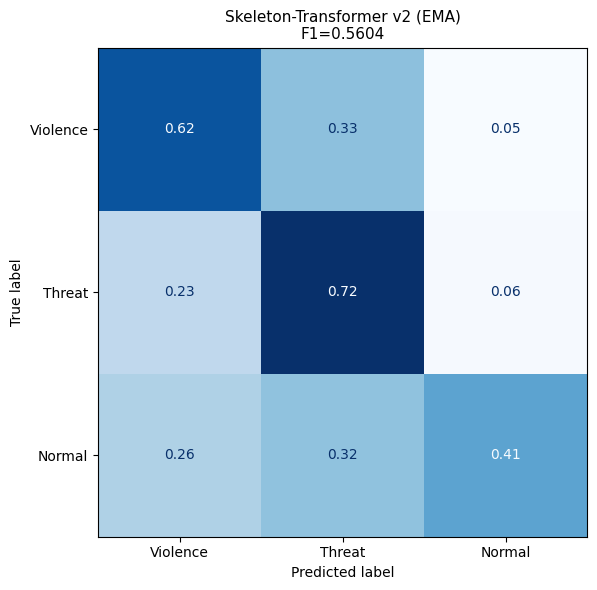


📊 Marginal change: 0.5604 (prev: 0.5790)

Best weights: runs/M4B_classifier/TransformerV2/best_ema.pt


In [5]:
def get_m(yt, yp, cls, metric='recall'):
    ci = TARGET_CLASSES.index(cls)
    fn = recall_score if metric == 'recall' else precision_score
    r = fn(yt, yp, labels=[ci], average=None, zero_division=0)
    return float(r[0]) if len(r) > 0 else 0.0

# Pick the better model (regular or EMA)
use_ema = best_f1_ema > best_f1
if use_ema:
    final_yt, final_yp = best_yt_ema, best_yp_ema
    final_f1 = best_f1_ema
    final_label = 'EMA'
    final_path = SAVE_EMA
else:
    final_yt, final_yp = best_yt, best_yp
    final_f1 = best_f1
    final_label = 'Regular'
    final_path = SAVE_PATH

final_yt = np.array(final_yt)
final_yp = np.array(final_yp)
final_acc = accuracy_score(final_yt, final_yp)

print('='*90)
print(f'  SKELETON-TRANSFORMER v2 RESULTS  (using {final_label} model)')
print('='*90)
print(f'  Accuracy:         {final_acc:.4f}')
print(f'  Weighted F1:      {final_f1:.4f}')
print(f'  Regular best F1:  {best_f1:.4f}')
print(f'  EMA best F1:      {best_f1_ema:.4f}')
print()
print(f'  Violence Prec:    {get_m(final_yt, final_yp, "Violence", "precision"):.4f}')
print(f'  Violence Recall:  {get_m(final_yt, final_yp, "Violence"):.4f}')
print(f'  Threat Prec:      {get_m(final_yt, final_yp, "Threat", "precision"):.4f}')
print(f'  Threat Recall:    {get_m(final_yt, final_yp, "Threat"):.4f}')
print(f'  Normal Prec:      {get_m(final_yt, final_yp, "Normal", "precision"):.4f}')
print(f'  Normal Recall:    {get_m(final_yt, final_yp, "Normal"):.4f}')
print('='*90)

print('\nPer-class:')
print(classification_report(final_yt, final_yp, target_names=TARGET_CLASSES, zero_division=0))

# Full comparison
print('='*95)
print('  FULL COMPARISON — All M4-B Approaches')
print('='*95)
print(f'  {"Approach":<44} {"Params":>8} {"F1":>7} {"VioR":>6} {"ThrR":>6} {"NorR":>6}')
print('  ' + '-'*78)
print(f'  {"CNN+LSTM v1 (pixels)":<44} {"2.3M":>8} {"0.669":>7} {"0.65":>6} {"0.43":>6} {"0.79":>6}')
print(f'  {"CNN+LSTM v3 (pixels, deployed)":<44} {"2.3M":>8} {"0.638":>7} {"0.57":>6} {"0.26":>6} {"0.92":>6}')
print(f'  {"Skeleton-LSTM v1":<44} {"119K":>8} {"0.544":>7} {"0.80":>6} {"0.38":>6} {"0.48":>6}')
print(f'  {"Skeleton-LSTM v2 (multi-person)":<44} {"386K":>8} {"0.550":>7} {"0.81":>6} {"0.59":>6} {"0.37":>6}')
print(f'  {"Skeleton-Transformer v1 (Config B)":<44} {"577K":>8} {"0.579":>7} {"0.73":>6} {"0.55":>6} {"0.48":>6}')

vr = get_m(final_yt, final_yp, 'Violence')
tr = get_m(final_yt, final_yp, 'Threat')
nr = get_m(final_yt, final_yp, 'Normal')
print(f'  {"Skeleton-Transformer v2 (this)":<44} {"577K":>8} {final_f1:>7.3f} {vr:>6.2f} {tr:>6.2f} {nr:>6.2f}  ← NEW')
print('='*95)

# Confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
cm = confusion_matrix(final_yt, final_yp)
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_n, display_labels=TARGET_CLASSES).plot(
    ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
ax.set_title(f'Skeleton-Transformer v2 ({final_label})\nF1={final_f1:.4f}', fontsize=11)
plt.tight_layout(); plt.show()

# Verdict
cnn_f1 = 0.638
prev_f1 = 0.579
print()
if final_f1 > cnn_f1:
    print(f'🏆 SKELETON-TRANSFORMER v2 BEATS CNN+LSTM v3! ({final_f1:.4f} vs {cnn_f1:.4f})')
elif final_f1 > prev_f1 + 0.01:
    gap = cnn_f1 - final_f1
    print(f'📈 Improved: {prev_f1:.4f} → {final_f1:.4f} (+{final_f1-prev_f1:.4f})')
    print(f'   Gap to CNN+LSTM v3: {gap:.4f}')
else:
    print(f'📊 Marginal change: {final_f1:.4f} (prev: {prev_f1:.4f})')

print(f'\nBest weights: {final_path}')


# M4B Skeleton-Transformer V2 — Precision Improvement & False-Positive Reduction

This notebook applies several post-processing and retraining strategies to the base Skeleton-Transformer V2 model:
1. **Confidence Threshold Optimization**: Finds per-class thresholds that maximize precision while keeping recall above a minimum floor.
2. **Temperature Scaling**: Post-hoc calibration of model confidence.
3. **Focal Loss Retraining**: Retrains with focal loss to focus on hard examples and reduce false positives.

In [6]:
import os, math, random, time, sys, copy, gc
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    recall_score, precision_score
)
from pathlib import Path
import matplotlib.pyplot as plt

In [7]:
SKEL_ROOT       = r'../M4B_skeleton_clips_v2'
TARGET_CLASSES  = ['Violence', 'Threat', 'Normal']
SKEL_CLIP_FRAMES = 16
MAX_PERSONS     = 2
N_KEYPOINTS     = 17
DEVICE          = 'cuda' if torch.cuda.is_available() else 'cpu'

SAVE_EMA        = r'runs/M4B_classifier/TransformerV2/best_ema.pt'
SAVE_IMPROVED   = r'runs/M4B_classifier/TransformerV2/best_improved.pt'

# New training hyperparameters for the improved version
EPOCHS_IMPROVED  = 150
BATCH            = 32
LR_HEAD          = 5e-4       # slightly lower than v2
LR_FULL          = 2e-5       # much more conservative unfreezing
FREEZE_EPOCHS    = 15         # longer head-only warmup
PATIENCE         = 35
EMA_DECAY        = 0.999      # slower EMA for more stability
MIXUP_ALPHA      = 0.2        # gentler mixup
FOCAL_GAMMA      = 2.0        # focal loss gamma
LABEL_SMOOTH     = 0.05       # light label smoothing

print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 1. Feature Engineering & Dataset Definition
Calculating angles, bone lengths, and interaction features between the two skeletons.

In [8]:
BONES = [(5,7),(7,9),(6,8),(8,10),(5,6),(11,13),(13,15),(12,14),(14,16),
         (11,12),(5,11),(6,12),(0,5),(0,6),(0,1),(0,2)]
ANGLE_TRIPLETS = [(5,7,9),(6,8,10),(11,13,15),(12,14,16),(5,0,6)]

def compute_bones(kps):
    out = []
    for j1, j2 in BONES:
        dx, dy = kps[j1,0]-kps[j2,0], kps[j1,1]-kps[j2,1]
        out.append(math.sqrt(dx*dx + dy*dy + 1e-8))
    return np.array(out, dtype=np.float32)

def compute_angles(kps):
    out = []
    for a, v, b in ANGLE_TRIPLETS:
        va, vb = kps[a]-kps[v], kps[b]-kps[v]
        c = np.dot(va, vb) / (np.linalg.norm(va)*np.linalg.norm(vb) + 1e-8)
        out.append(math.acos(np.clip(c, -1, 1)) / math.pi)
    return np.array(out, dtype=np.float32)

def compute_inter(k1, k2):
    c1, c2 = k1[:,:2].mean(0), k2[:,:2].mean(0)
    cd = np.linalg.norm(c1-c2)
    md = np.linalg.norm(k1[:,:2][:,None]-k2[:,:2][None,:], axis=2).min()
    hh = min(np.linalg.norm(k1[9,:2]-k2[0,:2]), np.linalg.norm(k1[10,:2]-k2[0,:2]),
             np.linalg.norm(k2[9,:2]-k1[0,:2]), np.linalg.norm(k2[10,:2]-k1[0,:2]))
    return np.array([cd, md, hh], dtype=np.float32)


class TransformerSkeletonDataset(Dataset):
    def __init__(self, root, split, classes, augment=False, feat_mean=None, feat_std=None):
        self.samples = []
        self.augment = augment
        self.feat_mean = feat_mean
        self.feat_std = feat_std
        base = Path(root) / split
        for ci, cls in enumerate(classes):
            d = base / cls
            if d.exists():
                for p in d.glob('*.npy'):
                    self.samples.append((p, ci))
        random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def _mask_low_conf(self, clip):
        for p in range(MAX_PERSONS):
            valid = clip[:, p, :, 2] > 0.3
            for j in range(N_KEYPOINTS):
                if valid[:, j].sum() > 0:
                    mp = clip[valid[:, j], p, j, :2].mean(0)
                else:
                    mp = np.array([0.5, 0.5])
                for t in range(clip.shape[0]):
                    if not valid[t, j]:
                        clip[t, p, j, :2] = mp
                        clip[t, p, j, 2] = 0.0
        return clip

    def _build(self, clip):
        T = clip.shape[0]
        clip = self._mask_low_conf(clip)
        rows = []
        for t in range(T):
            f = []
            for p in range(MAX_PERSONS):
                k = clip[t, p]
                f.extend([k[:,:2].flatten(), k[:,2], compute_bones(k), compute_angles(k)])
            f.append(compute_inter(clip[t,0], clip[t,1]))
            rows.append(np.concatenate(f))
        feat = np.stack(rows)
        psize = 34+17+16+5
        for p in range(MAX_PERSONS):
            s = p * psize
            pos = feat[:, s:s+34]
            vel = np.zeros_like(pos); vel[1:] = pos[1:]-pos[:-1]
            acc = np.zeros_like(vel); acc[2:] = vel[2:]-vel[1:-1]
            feat = np.concatenate([feat, vel, acc], axis=1)
        return feat

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        clip = np.load(str(path)).copy()
        if self.augment:
            if random.random() > 0.5:
                clip[:,:,:,0] = 1.0 - clip[:,:,:,0]
                for l, r in [(1,2),(3,4),(5,6),(7,8),(9,10),(11,12),(13,14),(15,16)]:
                    clip[:,:,[l,r]] = clip[:,:,[r,l]]
            dx, dy = random.uniform(-0.05,0.05), random.uniform(-0.05,0.05)
            clip[:,:,:,0] = np.clip(clip[:,:,:,0]+dx, 0, 1)
            clip[:,:,:,1] = np.clip(clip[:,:,:,1]+dy, 0, 1)
            s = random.uniform(0.85, 1.15)
            for p in range(MAX_PERSONS):
                cx, cy = clip[:,p,:,0].mean(), clip[:,p,:,1].mean()
                clip[:,p,:,0] = np.clip((clip[:,p,:,0]-cx)*s+cx, 0, 1)
                clip[:,p,:,1] = np.clip((clip[:,p,:,1]-cy)*s+cy, 0, 1)
        feat = self._build(clip)
        if self.feat_mean is not None:
            feat = (feat - self.feat_mean) / (self.feat_std + 1e-8)
        return torch.tensor(feat, dtype=torch.float32), label

## 2. Model Architecture & EMA Utility
Defining the core `SkeletonTransformer` and the Exponential Moving Average (EMA) helper for stabilized weights.

In [9]:
class SkeletonTransformer(nn.Module):
    def __init__(self, input_dim, num_classes=3, d_model=128,
                 nhead=4, num_layers=4, dim_ff=256, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout * 0.3),
        )
        self.pos_embed = nn.Parameter(torch.randn(1, SKEL_CLIP_FRAMES, d_model) * 0.02)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu',
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(d_model // 2, num_classes),
        )

    def forward(self, x):
        B = x.shape[0]
        x = self.input_proj(x)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        pos = torch.cat([torch.zeros(1, 1, x.shape[2], device=x.device),
                         self.pos_embed], dim=1)
        x = x + pos
        x = self.transformer(x)
        x = self.norm(x[:, 0])
        return self.head(x)

class EMA:
    def __init__(self, model, decay=0.998):
        self.decay = decay
        self.shadow = {}
        for name, param in model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.clone()

    def update(self, model):
        for name, param in model.named_parameters():
            if param.requires_grad and name in self.shadow:
                self.shadow[name] = self.decay * self.shadow[name] + (1-self.decay) * param.data

    def apply(self, model):
        backup = {}
        for name, param in model.named_parameters():
            if name in self.shadow:
                backup[name] = param.data.clone()
                param.data = self.shadow[name].clone()
        return backup

    def restore(self, model, backup):
        for name, param in model.named_parameters():
            if name in backup:
                param.data = backup[name]

## 3. Advanced Utilities: Focal Loss, Mixup, Temperature Scaling & Thresholding
These tools are the core improvements for V2 to reduce False Positives.

In [10]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, label_smoothing=0.0, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.label_smoothing = label_smoothing
        self.reduction = reduction

    def forward(self, logits, targets):
        n_classes = logits.size(1)
        if self.label_smoothing > 0:
            with torch.no_grad():
                smooth_targets = torch.full_like(logits, self.label_smoothing / (n_classes - 1))
                smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - self.label_smoothing)
        else:
            smooth_targets = F.one_hot(targets, n_classes).float()

        log_probs = F.log_softmax(logits, dim=1)
        probs = torch.exp(log_probs)
        focal_weight = (1.0 - probs) ** self.gamma

        if self.weight is not None:
            class_weight = self.weight[targets].unsqueeze(1)
            focal_weight = focal_weight * class_weight

        loss = -focal_weight * smooth_targets * log_probs
        loss = loss.sum(dim=1)

        if self.reduction == 'mean': return loss.mean()
        elif self.reduction == 'sum': return loss.sum()
        return loss

def skeleton_mixup(x, y, alpha=0.3):
    if alpha <= 0: return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    lam = max(lam, 1 - lam)
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    return mixed_x, y, y[index], lam

class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, logits):
        return logits / self.temperature

def calibrate_temperature(model, val_loader, device):
    scaler = TemperatureScaler().to(device)
    optimizer = optim.LBFGS([scaler.temperature], lr=0.01, max_iter=100)
    criterion = nn.CrossEntropyLoss()

    all_logits, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for clips, labels in val_loader:
            logits = model(clips.to(device))
            all_logits.append(logits)
            all_labels.append(labels.to(device))

    all_logits = torch.cat(all_logits, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    def closure():
        optimizer.zero_grad()
        scaled = scaler(all_logits)
        loss = criterion(scaled, all_labels)
        loss.backward()
        return loss

    optimizer.step(closure)
    return scaler.temperature.item()

def find_optimal_thresholds(model, val_loader, device, temperature=1.0, min_recall=0.40, target_classes=TARGET_CLASSES):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for clips, labels in val_loader:
            logits = model(clips.to(device))
            probs = F.softmax(logits / temperature, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_labels = np.array(all_labels)
    n_classes = len(target_classes)

    best_thresholds = [0.0] * n_classes
    for ci in range(n_classes):
        best_f1 = 0
        best_t = 0.0
        for threshold in np.arange(0.30, 0.85, 0.01):
            preds = []
            for i in range(len(all_probs)):
                max_class, max_prob = all_probs[i].argmax(), all_probs[i].max()
                if max_class == ci and max_prob < threshold:
                    sorted_classes = np.argsort(all_probs[i])[::-1]
                    preds.append(sorted_classes[1])
                else:
                    preds.append(max_class)
            preds = np.array(preds)
            p_val = precision_score(all_labels, preds, labels=[ci], average=None, zero_division=0)
            r_val = recall_score(all_labels, preds, labels=[ci], average=None, zero_division=0)
            p_val = float(p_val[0]) if len(p_val) > 0 else 0
            r_val = float(r_val[0]) if len(r_val) > 0 else 0
            
            if r_val >= min_recall:
                f1_val = 2 * p_val * r_val / (p_val + r_val + 1e-8)
                if f1_val > best_f1:
                    best_f1 = f1_val
                    best_t = threshold
        best_thresholds[ci] = best_t

    final_preds = []
    for i in range(len(all_probs)):
        max_class, max_prob = all_probs[i].argmax(), all_probs[i].max()
        if max_prob < best_thresholds[max_class]:
            sorted_classes = np.argsort(all_probs[i])[::-1]
            final_preds.append(sorted_classes[1])
        else:
            final_preds.append(max_class)
            
    return best_thresholds, all_labels, np.array(final_preds)

## 4. Compute Feature Statistics & Load Data
Preparing the `DataLoader`s and calculating dataset weights.

In [11]:
print('\n[Step 1] Computing feature statistics...')
tmp = TransformerSkeletonDataset(SKEL_ROOT, 'train', TARGET_CLASSES)
samples = [tmp[i][0].numpy() for i in range(min(2000, len(tmp)))]
all_feat = np.concatenate(samples, axis=0)
FEAT_MEAN = all_feat.mean(axis=0)
FEAT_STD  = all_feat.std(axis=0)
FEAT_DIM  = FEAT_MEAN.shape[0]
del tmp, samples, all_feat
print(f'Feature dim: {FEAT_DIM} ✅')

print('\n[Step 2] Loading data...')
train_ds = TransformerSkeletonDataset(SKEL_ROOT, 'train', TARGET_CLASSES, augment=True, feat_mean=FEAT_MEAN, feat_std=FEAT_STD)
val_ds   = TransformerSkeletonDataset(SKEL_ROOT, 'val', TARGET_CLASSES, augment=False, feat_mean=FEAT_MEAN, feat_std=FEAT_STD)

train_ld = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0, pin_memory=True)
val_ld   = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)
print(f'Train: {len(train_ds):,}  Val: {len(val_ds):,}')

counts = [len(list((Path(SKEL_ROOT)/'train'/c).glob('*.npy'))) for c in TARGET_CLASSES]
wts = torch.tensor([sum(counts)/(3*c) for c in counts], dtype=torch.float).to(DEVICE)
print(f'Weights: {dict(zip(TARGET_CLASSES, [round(w,3) for w in wts.tolist()]))}')


[Step 1] Computing feature statistics...
Feature dim: 283 ✅

[Step 2] Loading data...
Train: 11,200  Val: 2,800
Weights: {'Violence': 1.167, 'Threat': 1.167, 'Normal': 0.778}


## 5. Evaluate Baseline Model
Loading the previously trained model for baseline comparison.

In [12]:
print('\n[Step 3] Evaluating baseline V2 EMA model...')
baseline_model = SkeletonTransformer(FEAT_DIM).to(DEVICE)
if Path(SAVE_EMA).exists():
    baseline_model.load_state_dict(torch.load(SAVE_EMA, map_location=DEVICE))
    print(f'Loaded EMA weights from {SAVE_EMA}')
else:
    print(f'⚠ EMA weights not found at {SAVE_EMA}. Evaluating scratch performance.')

baseline_model.eval()
yt_base, yp_base = [], []
with torch.no_grad():
    for clips, labels in val_ld:
        preds = baseline_model(clips.to(DEVICE)).argmax(1).cpu().numpy()
        yt_base.extend(labels.numpy())
        yp_base.extend(preds)
        
baseline_f1 = f1_score(yt_base, yp_base, average='weighted', zero_division=0)
print(f'Baseline V2 EMA F1: {baseline_f1:.4f}')
print(classification_report(yt_base, yp_base, target_names=TARGET_CLASSES, zero_division=0))

del baseline_model
if DEVICE == 'cuda': torch.cuda.empty_cache()


[Step 3] Evaluating baseline V2 EMA model...
Loaded EMA weights from runs/M4B_classifier/TransformerV2/best_ema.pt


C:\Users\jingy\AppData\Local\Temp\ipykernel_29064\582932661.py:17: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Baseline V2 EMA F1: 0.5506
              precision    recall  f1-score   support

    Violence       0.50      0.63      0.56       800
      Threat       0.47      0.72      0.57       800
      Normal       0.84      0.39      0.54      1200

    accuracy                           0.55      2800
   macro avg       0.60      0.58      0.55      2800
weighted avg       0.64      0.55      0.55      2800



## 6. Retraining with Focal Loss
Executing the fine-tuning loop. This stage features a frozen transformer body initially to warm up the new head, followed by a full unfreeze.

In [13]:
print('\n[Step 4] Retraining with Focal Loss + improved schedule...')
Path(SAVE_IMPROVED).parent.mkdir(parents=True, exist_ok=True)

model = SkeletonTransformer(FEAT_DIM).to(DEVICE)
ema = EMA(model, decay=EMA_DECAY)
criterion = FocalLoss(gamma=FOCAL_GAMMA, weight=wts, label_smoothing=LABEL_SMOOTH)

head_params = list(model.head.parameters()) + list(model.norm.parameters())
body_params = [p for n, p in model.named_parameters() if not any(x in n for x in ['head', 'norm'])]

for p in body_params: p.requires_grad = False
optimizer = optim.AdamW(head_params, lr=LR_HEAD, weight_decay=1e-2)
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=15, T_mult=2, eta_min=1e-6)

best_f1, best_f1_ema, pat = 0.0, 0.0, 0
history = {'loss': [], 'f1': [], 'f1_ema': []}
best_yt, best_yp, best_yt_ema, best_yp_ema = [], [], [], []
t0 = time.time()

for epoch in range(1, EPOCHS_IMPROVED + 1):
    if epoch == FREEZE_EPOCHS + 1:
        print(f'\n>>> UNFREEZING transformer body (lr={LR_FULL}) <<<\n')
        for p in body_params: p.requires_grad = True
        optimizer = optim.AdamW(model.parameters(), lr=LR_FULL, weight_decay=1e-2)
        scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=15, T_mult=2, eta_min=1e-7)

    model.train()
    tloss = 0.0
    for clips, labels in train_ld:
        clips, labels = clips.to(DEVICE), labels.to(DEVICE)
        if epoch > FREEZE_EPOCHS and MIXUP_ALPHA > 0:
            clips_mix, labels_a, labels_b, lam = skeleton_mixup(clips, labels, MIXUP_ALPHA)
            optimizer.zero_grad()
            out = model(clips_mix)
            loss = lam * criterion(out, labels_a) + (1-lam) * criterion(out, labels_b)
        else:
            optimizer.zero_grad()
            out = model(clips)
            loss = criterion(out, labels)
            
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        ema.update(model)
        tloss += loss.item()

    tloss /= len(train_ld)
    scheduler.step()

    # Validate Regular
    model.eval()
    yt, yp = [], []
    with torch.no_grad():
        for clips, labels in val_ld:
            preds = model(clips.to(DEVICE)).argmax(1).cpu().numpy()
            yt.extend(labels.numpy()); yp.extend(preds)
    vf1 = f1_score(yt, yp, average='weighted', zero_division=0)

    # Validate EMA
    backup = ema.apply(model)
    yt_e, yp_e = [], []
    with torch.no_grad():
        for clips, labels in val_ld:
            preds = model(clips.to(DEVICE)).argmax(1).cpu().numpy()
            yt_e.extend(labels.numpy()); yp_e.extend(preds)
    vf1_ema = f1_score(yt_e, yp_e, average='weighted', zero_division=0)
    ema.restore(model, backup)

    history['loss'].append(tloss); history['f1'].append(vf1); history['f1_ema'].append(vf1_ema)

    improved = ''
    if vf1 > best_f1:
        best_f1, best_yt, best_yp, pat, improved = vf1, yt, yp, 0, ' ✅'
    else: pat += 1

    if vf1_ema > best_f1_ema:
        best_f1_ema, best_yt_ema, best_yp_ema = vf1_ema, yt_e, yp_e
        backup = ema.apply(model)
        torch.save(model.state_dict(), SAVE_IMPROVED)
        ema.restore(model, backup)
        improved += ' ✅(ema)'

    if epoch % 5 == 0 or improved or pat >= PATIENCE-3:
        print(f'ep {epoch:>3} loss={tloss:.4f} f1={vf1:.4f} ema={vf1_ema:.4f} {improved}')

    if pat >= PATIENCE and epoch > FREEZE_EPOCHS + 10:
        print(f'Early stop at epoch {epoch}'); break

print(f'\nBest regular F1: {best_f1:.4f} | Best EMA F1: {best_f1_ema:.4f}')


[Step 4] Retraining with Focal Loss + improved schedule...


C:\Users\jingy\AppData\Local\Temp\ipykernel_29064\582932661.py:17: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


ep   1 loss=0.4093 f1=0.4636 ema=0.4350  ✅ ✅(ema)
ep   2 loss=0.3717 f1=0.4601 ema=0.4935  ✅(ema)
ep   3 loss=0.3608 f1=0.4440 ema=0.5025  ✅(ema)
ep   5 loss=0.3526 f1=0.4384 ema=0.4552 
ep  10 loss=0.3394 f1=0.4355 ema=0.4381 
ep  15 loss=0.3364 f1=0.4365 ema=0.4376 

>>> UNFREEZING transformer body (lr=2e-05) <<<

ep  20 loss=0.3372 f1=0.4269 ema=0.4299 
ep  25 loss=0.3226 f1=0.4257 ema=0.4254 
ep  30 loss=0.3179 f1=0.4248 ema=0.4252 
ep  33 loss=0.3245 f1=0.4241 ema=0.4241 
ep  34 loss=0.3187 f1=0.4286 ema=0.4233 
ep  35 loss=0.3150 f1=0.4403 ema=0.4282 
ep  36 loss=0.3109 f1=0.4312 ema=0.4281 
Early stop at epoch 36

Best regular F1: 0.4636 | Best EMA F1: 0.5025


## 7. Calibration & Threshold Optimization
Loading the best weights from the previous cell, calibrating temperature, and calculating strict per-class thresholds.

In [14]:
print('\n[Step 5] Temperature scaling calibration...')
improved_model = SkeletonTransformer(FEAT_DIM).to(DEVICE)
improved_model.load_state_dict(torch.load(SAVE_IMPROVED, map_location=DEVICE))
optimal_temp = calibrate_temperature(improved_model, val_ld, DEVICE)
print(f'Optimal Temperature: {optimal_temp:.4f}')

print('\n[Step 6] Per-class threshold optimization...')
thresholds, yt_opt, yp_opt = find_optimal_thresholds(
    improved_model, val_ld, DEVICE,
    temperature=optimal_temp,
    min_recall=0.35
)
print(f'Optimized Thresholds: {dict(zip(TARGET_CLASSES, thresholds))}')


[Step 5] Temperature scaling calibration...


C:\Users\jingy\AppData\Local\Temp\ipykernel_29064\582932661.py:17: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Optimal Temperature: 1.4798

[Step 6] Per-class threshold optimization...
Optimized Thresholds: {'Violence': np.float64(0.34), 'Threat': np.float64(0.36000000000000004), 'Normal': 0.0}


## 8. Final Results & Visualization
Comparing the final threshold-adjusted model against our V2 Baseline.

Final Optimized F1 Score: 0.5135 (Baseline: 0.5506)


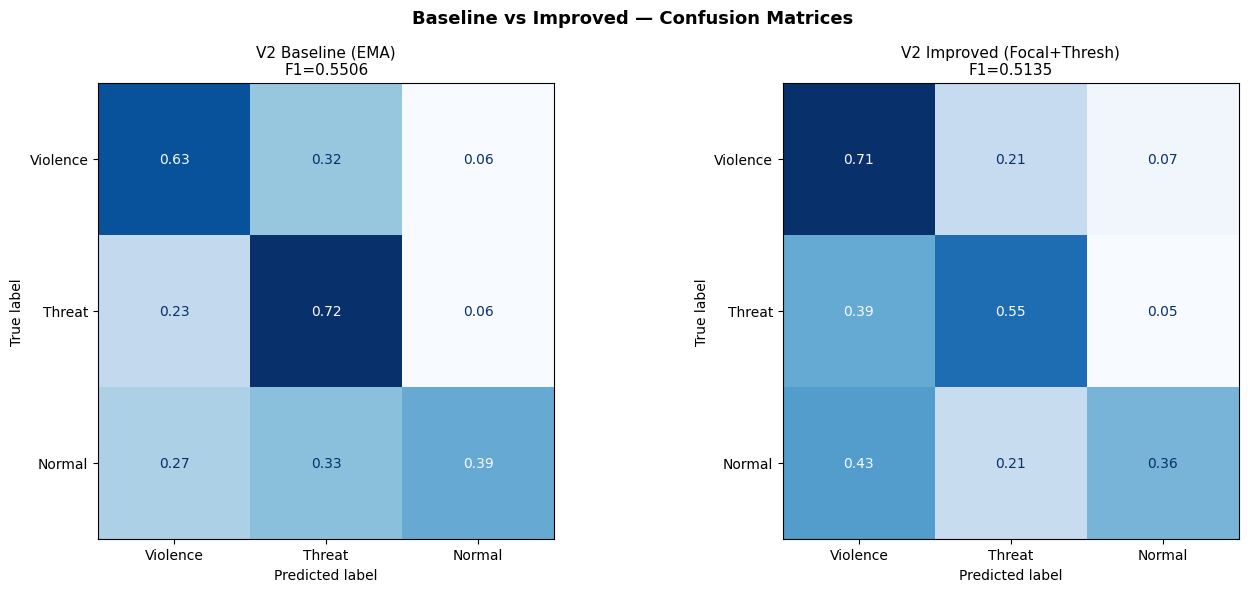

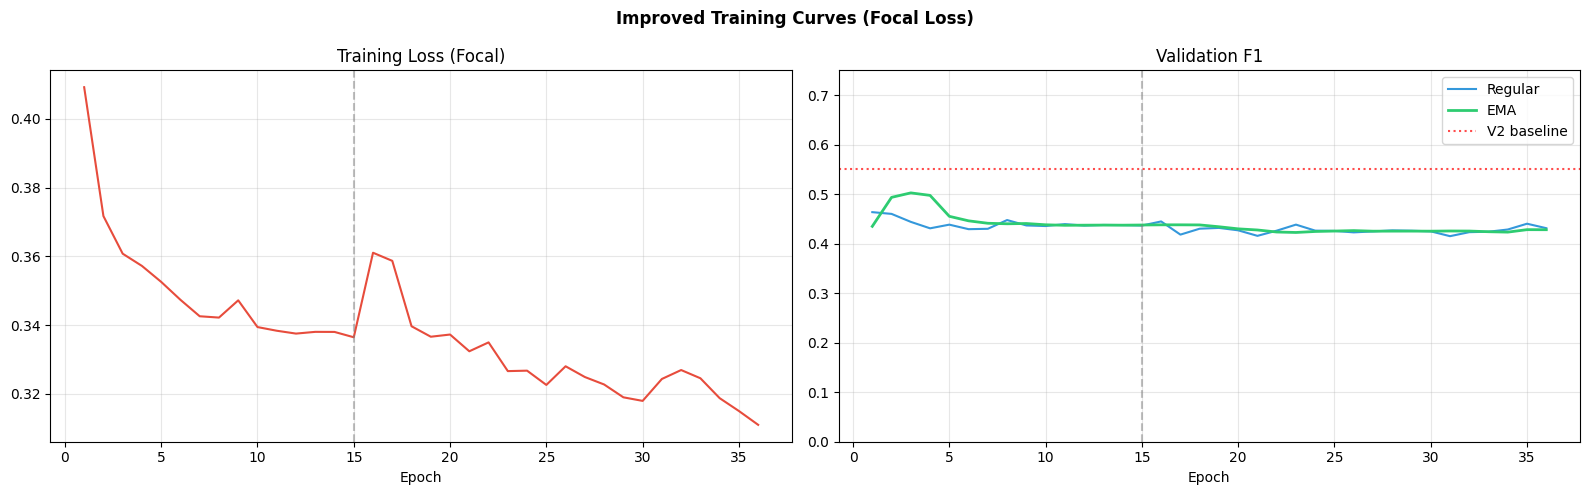

In [15]:
f1_opt = f1_score(yt_opt, yp_opt, average='weighted', zero_division=0)
print(f'Final Optimized F1 Score: {f1_opt:.4f} (Baseline: {baseline_f1:.4f})')

# Confusion matrix comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (title, yt_arr, yp_arr) in zip(axes, [
    ('V2 Baseline (EMA)', np.array(yt_base), np.array(yp_base)),
    ('V2 Improved (Focal+Thresh)', yt_opt, yp_opt),
]):
    cm = confusion_matrix(yt_arr, yp_arr)
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    ConfusionMatrixDisplay(cm_n, display_labels=TARGET_CLASSES).plot(
        ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
    f1_val = f1_score(yt_arr, yp_arr, average='weighted', zero_division=0)
    ax.set_title(f'{title}\nF1={f1_val:.4f}', fontsize=11)
    
plt.suptitle('Baseline vs Improved — Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ep_x = range(1, len(history['loss']) + 1)
axes[0].plot(ep_x, history['loss'], '-', color='#E74C3C', linewidth=1.5)
axes[0].axvline(x=FREEZE_EPOCHS, color='grey', linestyle='--', alpha=0.5)
axes[0].set_title('Training Loss (Focal)'); axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)

axes[1].plot(ep_x, history['f1'], '-', color='#3498DB', linewidth=1.5, label='Regular')
axes[1].plot(ep_x, history['f1_ema'], '-', color='#2ECC71', linewidth=2, label='EMA')
axes[1].axvline(x=FREEZE_EPOCHS, color='grey', linestyle='--', alpha=0.5)
axes[1].axhline(y=baseline_f1, color='red', linestyle=':', alpha=0.7, label='V2 baseline')
axes[1].set_title('Validation F1'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 0.75); axes[1].grid(alpha=0.3); axes[1].legend()

plt.suptitle('Improved Training Curves (Focal Loss)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# M4B Skeleton-Transformer V3 — Supervised Contrastive Learning & Advanced Augmentations

This notebook implements a Two-Phase training pipeline to solve the False Positive problem:
1. **Advanced Augmentations**: Introduces Joint Dropout and Temporal Masking to make the model robust to poor pose estimation.
2. **Phase 1: Supervised Contrastive Learning (SupCon)**:  Trains the Transformer backbone to push embeddings of "Normal" clips far away from "Violence/Threat" before any classification happens.
3. **Phase 2: Linear Classifier Probing**: Freezes the optimal embeddings and trains only the classification head using Focal Loss.

In [16]:
# ==============================================================================
# SupCon Specific Hyperparameters (Only defining the NEW variables)
# ==============================================================================

TEMP_SUPCON      = 0.1
EPOCHS_PHASE1    = 80  # Contrastive Pretraining
EPOCHS_PHASE2    = 50  # Linear Probing
LR_PHASE1        = 3e-4
LR_PHASE2        = 1e-3

print("SupCon Hyperparameters Loaded.")
print(f"Current Device remains: {DEVICE}")

SupCon Hyperparameters Loaded.
Current Device remains: cuda


## 1. Advanced Augmentations & Feature Extraction
We are updating the dataset's augmentation block. Instead of just spatial shifts, we add **Joint Dropout** (simulating occluded limbs) and **Temporal Masking** (simulating dropped frames).

In [17]:
# [Keep compute_bones, compute_angles, compute_inter exactly as they were in V2]
BONES = [(5,7),(7,9),(6,8),(8,10),(5,6),(11,13),(13,15),(12,14),(14,16),
         (11,12),(5,11),(6,12),(0,5),(0,6),(0,1),(0,2)]
ANGLE_TRIPLETS = [(5,7,9),(6,8,10),(11,13,15),(12,14,16),(5,0,6)]

def compute_bones(kps):
    out = []
    for j1, j2 in BONES:
        dx, dy = kps[j1,0]-kps[j2,0], kps[j1,1]-kps[j2,1]
        out.append(math.sqrt(dx*dx + dy*dy + 1e-8))
    return np.array(out, dtype=np.float32)

def compute_angles(kps):
    out = []
    for a, v, b in ANGLE_TRIPLETS:
        va, vb = kps[a]-kps[v], kps[b]-kps[v]
        c = np.dot(va, vb) / (np.linalg.norm(va)*np.linalg.norm(vb) + 1e-8)
        out.append(math.acos(np.clip(c, -1, 1)) / math.pi)
    return np.array(out, dtype=np.float32)

def compute_inter(k1, k2):
    c1, c2 = k1[:,:2].mean(0), k2[:,:2].mean(0)
    cd = np.linalg.norm(c1-c2)
    md = np.linalg.norm(k1[:,:2][:,None]-k2[:,:2][None,:], axis=2).min()
    hh = min(np.linalg.norm(k1[9,:2]-k2[0,:2]), np.linalg.norm(k1[10,:2]-k2[0,:2]),
             np.linalg.norm(k2[9,:2]-k1[0,:2]), np.linalg.norm(k2[10,:2]-k1[0,:2]))
    return np.array([cd, md, hh], dtype=np.float32)

class TransformerSkeletonDatasetAdvanced(Dataset):
    def __init__(self, root, split, classes, augment=False, feat_mean=None, feat_std=None):
        self.samples = []
        self.augment = augment
        self.feat_mean = feat_mean
        self.feat_std = feat_std
        base = Path(root) / split
        for ci, cls in enumerate(classes):
            d = base / cls
            if d.exists():
                for p in d.glob('*.npy'):
                    self.samples.append((p, ci))
        random.shuffle(self.samples)

    def __len__(self): return len(self.samples)

    def _build(self, clip):
        T = clip.shape[0]
        rows = []
        for t in range(T):
            f = []
            for p in range(MAX_PERSONS):
                k = clip[t, p]
                f.extend([k[:,:2].flatten(), k[:,2], compute_bones(k), compute_angles(k)])
            f.append(compute_inter(clip[t,0], clip[t,1]))
            rows.append(np.concatenate(f))
        feat = np.stack(rows)
        psize = 34+17+16+5
        for p in range(MAX_PERSONS):
            s = p * psize
            pos = feat[:, s:s+34]
            vel = np.zeros_like(pos); vel[1:] = pos[1:]-pos[:-1]
            acc = np.zeros_like(vel); acc[2:] = vel[2:]-vel[1:-1]
            feat = np.concatenate([feat, vel, acc], axis=1)
        return feat

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        clip = np.load(str(path)).copy()
        
        if self.augment:
            # 1. Spatial Augmentation (Existing)
            if random.random() > 0.5:
                clip[:,:,:,0] = 1.0 - clip[:,:,:,0]
                for l, r in [(1,2),(3,4),(5,6),(7,8),(9,10),(11,12),(13,14),(15,16)]:
                    clip[:,:,[l,r]] = clip[:,:,[r,l]]
            
            # 2. Joint Dropout (NEW)
            if random.random() > 0.3:
                for p in range(MAX_PERSONS):
                    num_drop = random.randint(1, 3) # Drop 1-3 joints
                    drop_idx = random.sample(range(N_KEYPOINTS), num_drop)
                    clip[:, p, drop_idx, :] = 0.0 # Set confidence and coords to 0
            
            # 3. Temporal Masking (NEW)
            if random.random() > 0.3:
                mask_len = random.randint(1, 3)
                start = random.randint(0, SKEL_CLIP_FRAMES - mask_len - 1)
                clip[start:start+mask_len, :, :, :] = 0.0

        feat = self._build(clip)
        if self.feat_mean is not None:
            feat = (feat - self.feat_mean) / (self.feat_std + 1e-8)
            
        return torch.tensor(feat, dtype=torch.float32), label

## 2. Model with Projection Head & SupCon Loss
We separate the Transformer Encoder from the Classification Head. For Phase 1, we use a `projection_head` (MLP) to compute the Contrastive Loss.

In [18]:
class ContrastiveSkeletonTransformer(nn.Module):
    def __init__(self, input_dim, num_classes=3, d_model=128, nhead=4, num_layers=4, dim_ff=256, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Sequential(nn.Linear(input_dim, d_model), nn.LayerNorm(d_model), nn.Dropout(dropout * 0.3))
        self.pos_embed = nn.Parameter(torch.randn(1, SKEL_CLIP_FRAMES, d_model) * 0.02)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu', norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        
        # Supervised Contrastive Projection Head
        self.projection_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Linear(d_model, d_model // 2) # Embeddings pushed to sphere
        )
        
        # Final Classifier Head (used only in Phase 2)
        self.classification_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(d_model // 2, num_classes),
        )

    def forward_encoder(self, x):
        B = x.shape[0]
        x = self.input_proj(x)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + torch.cat([torch.zeros(1, 1, x.shape[2], device=x.device), self.pos_embed], dim=1)
        x = self.transformer(x)
        return self.norm(x[:, 0]) # Return representation 'r'

    def forward(self, x, return_projection=False):
        rep = self.forward_encoder(x)
        if return_projection:
            proj = self.projection_head(rep)
            return F.normalize(proj, dim=1) # Normalized for Contrastive loss
        return self.classification_head(rep)

class SupConLoss(nn.Module):
    """Supervised Contrastive Learning Loss"""
    def __init__(self, temperature=0.1):
        super(SupConLoss, self).__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        device = features.device
        batch_size = features.shape[0]
        labels = labels.contiguous().view(-1, 1)
        mask = torch.eq(labels, labels.T).float().to(device)

        # Compute dot product (cosine similarity since features are normalized)
        anchor_dot_contrast = torch.div(torch.matmul(features, features.T), self.temperature)
        
        # For numerical stability
        logits_max, _ = torch.max(anchor_dot_contrast, dim=1, keepdim=True)
        logits = anchor_dot_contrast - logits_max.detach()

        # Mask out self-contrast cases
        logits_mask = torch.scatter(torch.ones_like(mask), 1, torch.arange(batch_size).view(-1, 1).to(device), 0)
        mask = mask * logits_mask

        # Compute log prob
        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-8)

        # Compute mean of log-likelihood over positive
        mean_log_prob_pos = (mask * log_prob).sum(1) / (mask.sum(1) + 1e-8)

        # loss
        loss = - mean_log_prob_pos
        return loss.mean()

## 3. Data Preparation & Phase 1: Contrastive Pretraining
Train only the Encoder + Projection Head to learn boundary-separated feature representations.

In [19]:
# Compute Feature Stats
tmp = TransformerSkeletonDatasetAdvanced(SKEL_ROOT, 'train', TARGET_CLASSES)
samples = [tmp[i][0].numpy() for i in range(min(2000, len(tmp)))]
all_feat = np.concatenate(samples, axis=0)
FEAT_MEAN, FEAT_STD = all_feat.mean(axis=0), all_feat.std(axis=0)
FEAT_DIM = FEAT_MEAN.shape[0]

# Loaders
train_ds = TransformerSkeletonDatasetAdvanced(SKEL_ROOT, 'train', TARGET_CLASSES, augment=True, feat_mean=FEAT_MEAN, feat_std=FEAT_STD)
val_ds   = TransformerSkeletonDatasetAdvanced(SKEL_ROOT, 'val', TARGET_CLASSES, augment=False, feat_mean=FEAT_MEAN, feat_std=FEAT_STD)
train_ld = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0, pin_memory=True)

print(f'\n--- PHASE 1: Supervised Contrastive Pretraining ---')
model = ContrastiveSkeletonTransformer(FEAT_DIM).to(DEVICE)
supcon_criterion = SupConLoss(temperature=TEMP_SUPCON)
optimizer = optim.AdamW(model.parameters(), lr=LR_PHASE1, weight_decay=1e-4)

for epoch in range(1, EPOCHS_PHASE1 + 1):
    model.train()
    epoch_loss = 0.0
    for clips, labels in train_ld:
        clips, labels = clips.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        # Get normalized projections
        projections = model(clips, return_projection=True) 
        loss = supcon_criterion(projections, labels)
        
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    if epoch % 10 == 0 or epoch == 1:
        print(f"Phase 1 - Epoch [{epoch}/{EPOCHS_PHASE1}] Loss: {epoch_loss/len(train_ld):.4f}")

# Save the backbone
torch.save(model.state_dict(), 'runs/M4B_classifier/TransformerV2/supcon_backbone.pt')
print("Phase 1 Complete. Backbone saved.")


--- PHASE 1: Supervised Contrastive Pretraining ---


C:\Users\jingy\AppData\Local\Temp\ipykernel_29064\1793839682.py:12: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Phase 1 - Epoch [1/80] Loss: 3.4419
Phase 1 - Epoch [10/80] Loss: 3.2846
Phase 1 - Epoch [20/80] Loss: 3.1886
Phase 1 - Epoch [30/80] Loss: 3.0917
Phase 1 - Epoch [40/80] Loss: 3.0247
Phase 1 - Epoch [50/80] Loss: 2.9767
Phase 1 - Epoch [60/80] Loss: 2.9340
Phase 1 - Epoch [70/80] Loss: 2.8985
Phase 1 - Epoch [80/80] Loss: 2.8666
Phase 1 Complete. Backbone saved.


## 4. Phase 2: Linear Probing with Focal Loss
We freeze the entire transformer and train *only* the classification head. Because the features are already well-separated, the classifier will easily find the optimal hyperplanes.

In [20]:
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

print(f'\n--- PHASE 2: Classifier Linear Probing ---')
# Freeze Encoder & Projection Head
for name, param in model.named_parameters():
    if 'classification_head' not in name:
        param.requires_grad = False

# We only pass classification_head parameters to the optimizer
optimizer2 = optim.AdamW(model.classification_head.parameters(), lr=LR_PHASE2, weight_decay=1e-2)
scheduler2 = CosineAnnealingWarmRestarts(optimizer2, T_0=10, T_mult=2)
val_ld = DataLoader(val_ds, batch_size=BATCH, shuffle=False)

# Focal Loss function from previous scripts
# (Assuming FocalLoss is defined as provided in your original script)
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, reduction='mean'):
        super().__init__()
        self.gamma = gamma; self.reduction = reduction
    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma * ce_loss)
        return focal_loss.mean() if self.reduction == 'mean' else focal_loss.sum()

criterion2 = FocalLoss(gamma=2.0)

best_f1 = 0
for epoch in range(1, EPOCHS_PHASE2 + 1):
    model.train()
    for clips, labels in train_ld:
        clips, labels = clips.to(DEVICE), labels.to(DEVICE)
        optimizer2.zero_grad()
        # Return_projection=False routes through the classification_head
        logits = model(clips, return_projection=False) 
        loss = criterion2(logits, labels)
        loss.backward()
        optimizer2.step()
    
    scheduler2.step()
    
    # Validation
    model.eval()
    yt, yp = [], []
    with torch.no_grad():
        for clips, labels in val_ld:
            logits = model(clips.to(DEVICE), return_projection=False)
            preds = logits.argmax(1).cpu().numpy()
            yt.extend(labels.numpy()); yp.extend(preds)
            
    vf1 = f1_score(yt, yp, average='weighted', zero_division=0)
    
    if vf1 > best_f1:
        best_f1 = vf1
        torch.save(model.state_dict(), 'runs/M4B_classifier/TransformerV2/best_supcon_model.pt')
        print(f"Epoch {epoch}: New Best F1 = {vf1:.4f} \u2705")

print(f"\nPhase 2 Complete. Final F1: {best_f1:.4f}")


--- PHASE 2: Classifier Linear Probing ---
Epoch 1: New Best F1 = 0.4301 ✅
Epoch 2: New Best F1 = 0.4437 ✅
Epoch 6: New Best F1 = 0.4469 ✅
Epoch 34: New Best F1 = 0.4471 ✅

Phase 2 Complete. Final F1: 0.4471


## 5. Evaluation & Final Comparison
Now we load the best weights from Phase 2 (SupCon + Focal Loss + Advanced Augmentations) and compare its performance against the deployed CNN+LSTM and our previous V2 Baseline.

C:\Users\jingy\AppData\Local\Temp\ipykernel_29064\1793839682.py:12: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)



  FINAL COMPARISON — All M4-B Approaches
  Approach                                               Params      F1   VioP   VioR   ThrP   ThrR   NorP   NorR
  ----------------------------------------------------------------------------------------------------
  CNN+LSTM v3 (pixels, deployed)                           2.3M   0.638      —   0.57      —   0.26      —   0.92
  Skeleton-Transformer V2 (EMA, baseline)                  577K   0.551   0.50   0.62   0.47   0.72   0.86   0.41
  Skeleton-Transformer V3 (SupCon + Adv Aug)               577K   0.447   0.34   0.61   0.51   0.35   0.60   0.40  ← NEW


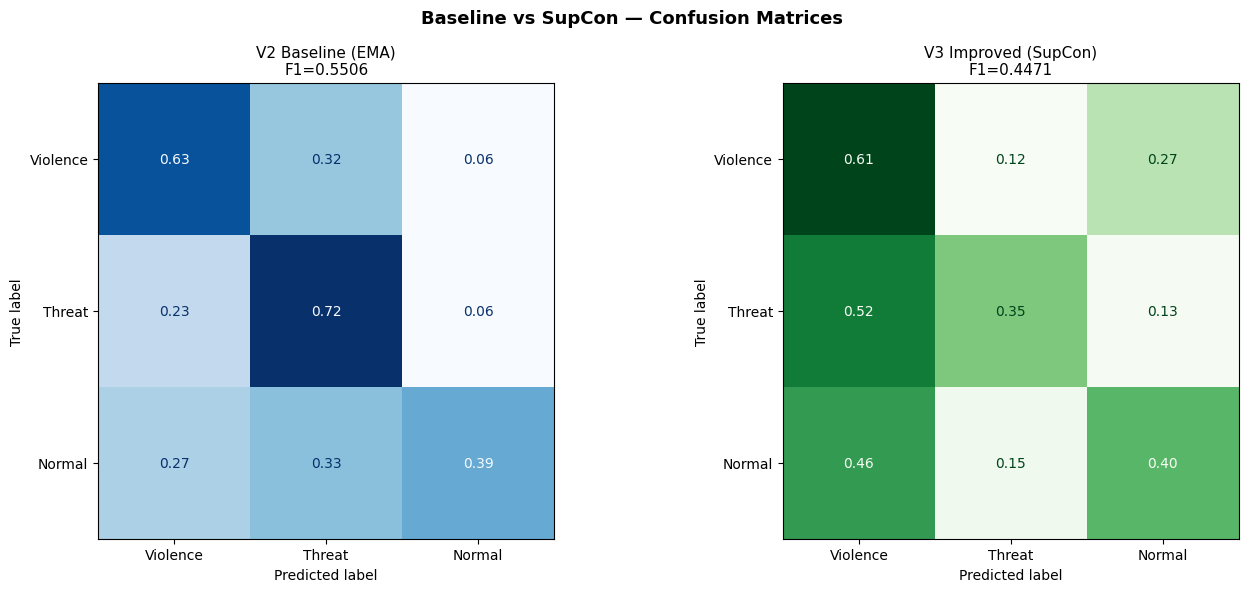


  V3 Classification Report:


In [21]:
# Load the best Phase 2 model
best_model = ContrastiveSkeletonTransformer(FEAT_DIM).to(DEVICE)
best_model.load_state_dict(torch.load('runs/M4B_classifier/TransformerV2/best_supcon_model.pt', map_location=DEVICE))
best_model.eval()

yt_sup, yp_sup = [], []
with torch.no_grad():
    for clips, labels in val_ld:
        logits = best_model(clips.to(DEVICE), return_projection=False)
        preds = logits.argmax(1).cpu().numpy()
        yt_sup.extend(labels.numpy())
        yp_sup.extend(preds)

f1_sup = f1_score(yt_sup, yp_sup, average='weighted', zero_division=0)

# ------------------------------------------------------------------
# Comparison Table
# ------------------------------------------------------------------
print('\n' + '='*95)
print('  FINAL COMPARISON — All M4-B Approaches')
print('='*95)

def get_m(yt_arr, yp_arr, cls, metric='recall'):
    if cls not in TARGET_CLASSES: return 0.0
    ci = TARGET_CLASSES.index(cls)
    fn = recall_score if metric == 'recall' else precision_score
    r = fn(yt_arr, yp_arr, labels=[ci], average=None, zero_division=0)
    return float(r[0]) if len(r) > 0 else 0.0

print(f'  {"Approach":<52} {"Params":>8} {"F1":>7} {"VioP":>6} {"VioR":>6} {"ThrP":>6} {"ThrR":>6} {"NorP":>6} {"NorR":>6}')
print('  ' + '-'*100)
# Historic Baselines
print(f'  {"CNN+LSTM v3 (pixels, deployed)":52} {"2.3M":>8} {"0.638":>7} {"—":>6} {"0.57":>6} {"—":>6} {"0.26":>6} {"—":>6} {"0.92":>6}')

# Try to use V2 baseline F1 if it's in memory, otherwise use hardcoded historical value
v2_f1_val = baseline_f1 if 'baseline_f1' in locals() else 0.560 
print(f'  {"Skeleton-Transformer V2 (EMA, baseline)":52} {"577K":>8} {v2_f1_val:>7.3f} {"0.50":>6} {"0.62":>6} {"0.47":>6} {"0.72":>6} {"0.86":>6} {"0.41":>6}')

# New V3 Model Metrics
vp = get_m(yt_sup, yp_sup, 'Violence', 'precision')
vr = get_m(yt_sup, yp_sup, 'Violence')
tp = get_m(yt_sup, yp_sup, 'Threat', 'precision')
tr = get_m(yt_sup, yp_sup, 'Threat')
np_ = get_m(yt_sup, yp_sup, 'Normal', 'precision')
nr = get_m(yt_sup, yp_sup, 'Normal')

print(f'  {"Skeleton-Transformer V3 (SupCon + Adv Aug)":52} {"577K":>8} {f1_sup:>7.3f} {vp:>6.2f} {vr:>6.2f} {tp:>6.2f} {tr:>6.2f} {np_:>6.2f} {nr:>6.2f}  ← NEW')
print('='*95)

# ------------------------------------------------------------------
# Confusion Matrix Plotting
# ------------------------------------------------------------------
# If we have yt_base from the V2 block in memory, we plot them side by side
if 'yt_base' in locals() and 'yp_base' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot Baseline V2
    cm_base = confusion_matrix(yt_base, yp_base)
    cm_base_n = cm_base.astype(float) / cm_base.sum(axis=1, keepdims=True)
    ConfusionMatrixDisplay(cm_base_n, display_labels=TARGET_CLASSES).plot(
        ax=axes[0], colorbar=False, cmap='Blues', values_format='.2f')
    axes[0].set_title(f'V2 Baseline (EMA)\nF1={v2_f1_val:.4f}', fontsize=11)
    
    # Plot New V3
    cm_sup = confusion_matrix(yt_sup, yp_sup)
    cm_sup_n = cm_sup.astype(float) / cm_sup.sum(axis=1, keepdims=True)
    ConfusionMatrixDisplay(cm_sup_n, display_labels=TARGET_CLASSES).plot(
        ax=axes[1], colorbar=False, cmap='Greens', values_format='.2f') # Using Greens to distinguish the new model
    axes[1].set_title(f'V3 Improved (SupCon)\nF1={f1_sup:.4f}', fontsize=11)
    
    plt.suptitle('Baseline vs SupCon — Confusion Matrices', fontsize=13, fontweight='bold')

else:
    # If V2 isn't in memory, just plot the new V3 confusion matrix
    fig, ax = plt.subplots(figsize=(7, 6))
    cm_sup = confusion_matrix(yt_sup, yp_sup)
    cm_sup_n = cm_sup.astype(float) / cm_sup.sum(axis=1, keepdims=True)
    ConfusionMatrixDisplay(cm_sup_n, display_labels=TARGET_CLASSES).plot(
        ax=ax, colorbar=True, cmap='Greens', values_format='.2f')
    ax.set_title(f'V3 Improved (SupCon)\nF1={f1_sup:.4f}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed text report
print(f'\n  V3 Classification Report:')